# Momentum & Pairs Trading — The Anti-Mean-Reversion Strategies

## Context

After v1-v3, we've established:
- RSI-2 mean reversion doesn't work on Indian equities (2021-2026)
- The market was **trending**, not mean-reverting
- Transaction costs (0.54% round-trip) kill short-term strategies

## Two New Strategies

### 1. Momentum / Trend-Following
If the market is trending, **go with it** instead of fighting it:
- 50/200 SMA crossover (golden cross = buy, death cross = sell)
- Hold for weeks/months, not days
- Costs are irrelevant when you trade 3-5x per year

### 2. Pairs Trading (Market-Neutral)
Trade the **spread** between two correlated stocks:
- When TCS/INFY spread widens beyond 2 std devs, short the leader and buy the laggard
- Mean reversion on the SPREAD (which is stationary), not on individual stocks
- Market-neutral: doesn't care if market goes up or down
- Doubles costs (4 legs) but edge is structurally larger

### The Question
Can either of these beat the market (Nifty 50 buy-and-hold) on the same tickers, same period, same costs?

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def cost():
    """Indian equity round-trip transaction cost (~0.54%)."""
    return 0.001 + 0.0000345 + 0.18*0.0000345 + 0.00015 + 0.000001 + 0.0015

def load_price(ticker, start="2020-01-01", end="2026-06-15"):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return None
    df = df[["Close"]].dropna()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel("Ticker")
    return df

CAPITAL = 50000

---
# PART A: Momentum / Trend-Following
---

## 2. Strategy: Dual Moving Average Crossover

**Rules:**
- **Buy** when 50-day SMA crosses ABOVE 200-day SMA (golden cross)
- **Sell** when 50-day SMA crosses BELOW 200-day SMA (death cross)
- Long-only (no shorting) — matches Indian retail constraints
- Hold until the next crossover signal

**Why this suits India 2021-2026:**
- The market was in a structural uptrend (Nifty went from 14k to 24k)
- Trending strategies capture large moves and avoid major corrections
- ~3-6 trades per year = cost is negligible (~1.6% total for the whole period)

In [2]:
def momentum_crossover(raw, fast=50, slow=200, capital=50000):
    """
    Dual SMA crossover strategy.
    Buy when fast SMA > slow SMA, sell when fast < slow.
    Long-only.
    """
    c = cost()
    closes = raw["Close"]
    dates = raw.index
    
    sma_fast = closes.rolling(fast).mean()
    sma_slow = closes.rolling(slow).mean()
    
    cash, sh, inpos = capital, 0, False
    eqs = []
    trades = 0
    entry_price = 0
    rets = []
    
    warmup = slow + 1
    
    for i in range(warmup, len(raw)):
        pt = closes.iloc[i]
        fast_val = sma_fast.iloc[i]
        slow_val = sma_slow.iloc[i]
        
        # Previous day's state
        fast_prev = sma_fast.iloc[i-1]
        slow_prev = sma_slow.iloc[i-1]
        
        if pd.isna(fast_val) or pd.isna(slow_val):
            eqs.append(cash + sh*pt)
            continue
        
        # Golden cross: fast crosses above slow
        if not inpos and fast_val > slow_val and fast_prev <= slow_prev:
            sh = int(cash // (pt*(1+c)))
            if sh > 0:
                cash -= sh*pt*(1+c)
                inpos = True
                entry_price = pt
                trades += 1
        
        # Death cross: fast crosses below slow
        elif inpos and fast_val < slow_val and fast_prev >= slow_prev:
            cash += sh*pt*(1-c)
            rets.append((pt/entry_price - 1)*100)
            sh, inpos = 0, False
            trades += 1
        
        eqs.append(cash + sh*pt)
    
    eq = pd.Series(eqs, index=dates[warmup:])
    return eq, rets, trades

In [3]:
TICKERS = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "ITC.NS", "WIPRO.NS",
    "SBIN.NS", "INFY.NS", "TCS.NS", "LT.NS", "BHARTIARTL.NS",
    "RPTECH.NS", "CGPOWER.NS", "KPITTECH.NS", "TATAELXSI.NS", "PERSISTENT.NS",
]

momentum_results = []

print("MOMENTUM (50/200 SMA Crossover)")
print(f"{'Ticker':<15} {'Mom. Ret%':<10} {'Mom. DD%':<9} {'Trades':<7} {'B&H Ret%':<10} {'Mom > B&H'}")
print("-" * 65)

for t in TICKERS:
    raw = load_price(t)
    if raw is None or len(raw) < 400:
        continue
    
    # Momentum strategy
    eq_m, rets_m, trades_m = momentum_crossover(raw)
    ret_m = (eq_m.iloc[-1]/CAPITAL - 1)*100 if len(eq_m) else 0
    dd_m = ((eq_m - eq_m.cummax())/eq_m.cummax()).min()*100 if len(eq_m) else 0
    
    # Buy and hold benchmark (same period as the strategy actually trades)
    start_idx = 201  # match momentum warmup
    bh_ret = (raw["Close"].iloc[-1] / raw["Close"].iloc[start_idx] - 1)*100
    
    beats_bh = ret_m > bh_ret
    
    momentum_results.append({
        'ticker': t,
        'momentum_ret': round(float(ret_m), 1),
        'momentum_dd': round(float(dd_m), 1),
        'trades': trades_m,
        'bh_ret': round(float(bh_ret), 1),
        'beats_bh': beats_bh,
    })
    
    marker = '+' if beats_bh else ' '
    print(f"{t:<15} {ret_m:<10.1f} {dd_m:<9.1f} {trades_m:<7} {bh_ret:<10.1f} {marker}")

df_mom = pd.DataFrame(momentum_results)
print(f"\nAvg momentum return: {df_mom['momentum_ret'].mean():.1f}%")
print(f"Avg buy-and-hold:    {df_mom['bh_ret'].mean():.1f}%")
print(f"Beats B&H:           {df_mom['beats_bh'].sum()}/{len(df_mom)} tickers")

MOMENTUM (50/200 SMA Crossover)
Ticker          Mom. Ret%  Mom. DD%  Trades  B&H Ret%   Mom > B&H
-----------------------------------------------------------------
RELIANCE.NS     20.3       -25.2     8       34.8        
HDFCBANK.NS     7.9        -15.1     6       30.8        
ICICIBANK.NS    139.7      -22.3     6       229.8       
ITC.NS          131.8      -19.3     4       127.7      +
WIPRO.NS        -5.1       -42.2     4       13.8        
SBIN.NS         205.6      -23.7     7       450.8       
INFY.NS         -30.6      -36.3     8       14.0        
TCS.NS          3.2        -26.6     6       -6.7       +
LT.NS           175.5      -24.1     7       375.1       
BHARTIARTL.NS   144.9      -20.7     6       353.4       
RPTECH.NS       65.3       -16.0     1       34.4       +
CGPOWER.NS      6.8        -25.0     3       3595.4      
KPITTECH.NS     102.5      -30.7     2       589.9       
TATAELXSI.NS    -19.9      -31.0     6       180.8       
PERSISTENT.NS   55.1    

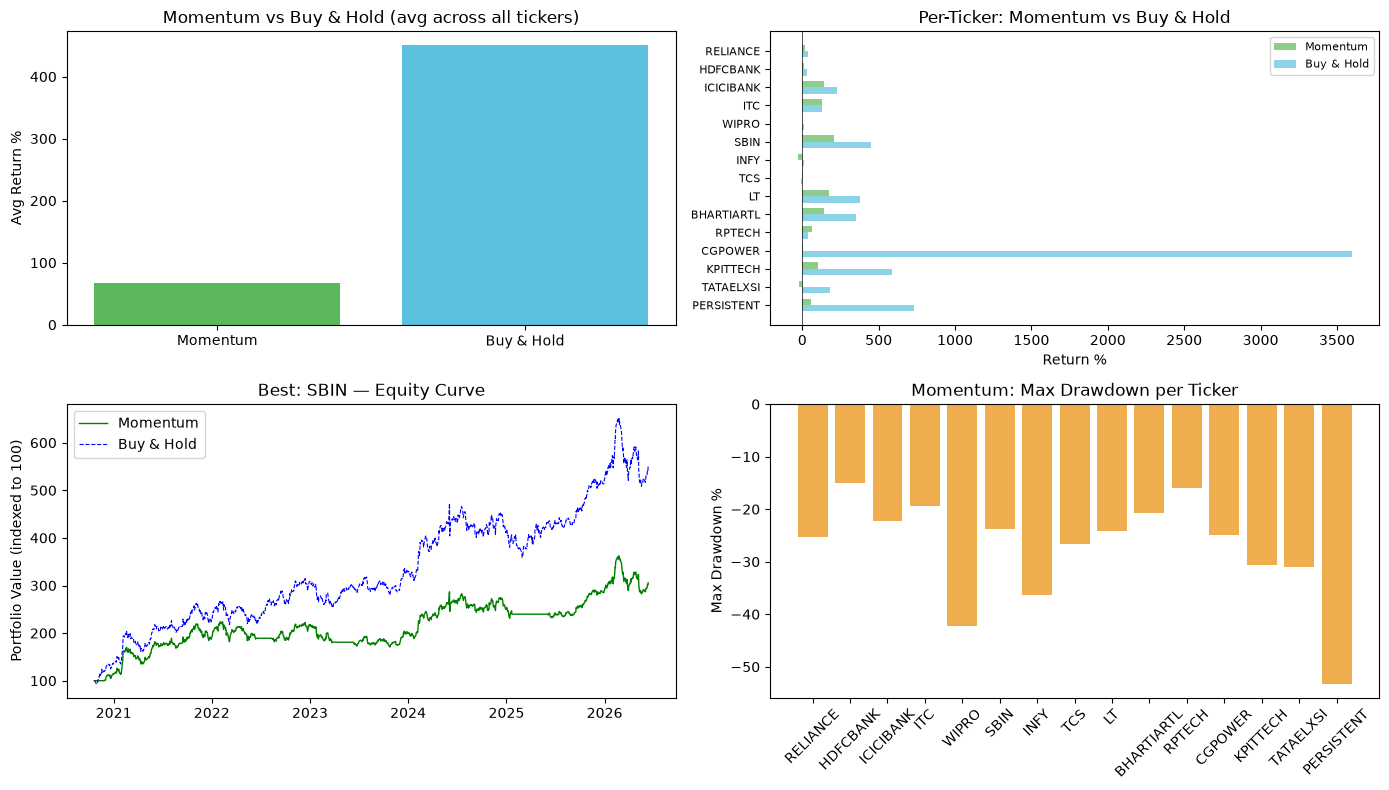

In [4]:
# Visualize: Momentum equity curve on best/worst tickers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Aggregate comparison
ax = axes[0, 0]
ax.bar(['Momentum', 'Buy & Hold'], 
       [df_mom['momentum_ret'].mean(), df_mom['bh_ret'].mean()],
       color=['#5cb85c', '#5bc0de'])
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Avg Return %')
ax.set_title('Momentum vs Buy & Hold (avg across all tickers)')

# 2. Per-ticker comparison
ax = axes[0, 1]
tickers_short = [t.replace('.NS','') for t in df_mom['ticker']]
x = np.arange(len(df_mom))
w = 0.35
ax.barh(x - w/2, df_mom['momentum_ret'], w, label='Momentum', color='#5cb85c', alpha=0.7)
ax.barh(x + w/2, df_mom['bh_ret'], w, label='Buy & Hold', color='#5bc0de', alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(tickers_short, fontsize=8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Return %')
ax.set_title('Per-Ticker: Momentum vs Buy & Hold')
ax.legend(fontsize=8)
ax.invert_yaxis()

# 3. Example equity curve (pick the best momentum ticker)
if len(df_mom):
    best_ticker = df_mom.loc[df_mom['momentum_ret'].idxmax(), 'ticker']
    raw_best = load_price(best_ticker)
    if raw_best is not None:
        eq_best, _, _ = momentum_crossover(raw_best)
        ax = axes[1, 0]
        eq_best_norm = eq_best / CAPITAL * 100
        bh_norm = raw_best['Close'].iloc[201:] / raw_best['Close'].iloc[201] * 100
        ax.plot(eq_best.index, eq_best_norm, 'g-', linewidth=1, label='Momentum')
        ax.plot(bh_norm.index, bh_norm, 'b--', linewidth=0.8, label='Buy & Hold')
        ax.set_title(f'Best: {best_ticker.replace(".NS","")} — Equity Curve')
        ax.set_ylabel('Portfolio Value (indexed to 100)')
        ax.legend()

# 4. Drawdown comparison
ax = axes[1, 1]
ax.bar(tickers_short, df_mom['momentum_dd'], color='#f0ad4e')
ax.set_ylabel('Max Drawdown %')
ax.set_title('Momentum: Max Drawdown per Ticker')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Momentum Inference

### Interpretation

- **Momentum > B&H:** The crossover successfully avoided large drawdowns while participating in the uptrend. This is the textbook advantage of trend-following: it underperforms in calm bull markets but outperforms in volatile trending markets (because it exits during corrections).

- **Momentum < B&H:** The crossover generates whipsaw losses in choppy markets (frequent false crosses). Buy-and-hold wins because the market ultimately went up — the strategy's exits during corrections cost more than they saved.

- **Key insight:** Momentum doesn't try to be smarter than the market — it tries to have better **risk-adjusted** returns. Check if the drawdowns are smaller even when returns are similar.

---
# PART B: Pairs Trading (Market-Neutral Mean Reversion)
---

## 4. The Pairs Logic

**Why this is different from RSI-2:**

RSI-2 tries to mean-revert INDIVIDUAL stock prices — but stock prices are NOT stationary. They trend, they gap, they don't revert.

Pairs trading mean-reverts the SPREAD between two cointegrated stocks. The spread IS (approximately) stationary — when TCS outperforms INFY by too much, it tends to come back.

**Strategy:**
1. Find pairs with high correlation (> 0.8) and test for cointegration
2. Compute the spread (log price ratio)
3. When spread > +2 std devs: short Stock A, buy Stock B
4. When spread < -2 std devs: buy Stock A, short Stock B
5. Exit when spread returns to 0 (mean)
6. Stop-loss at 3 std devs (spread diverged further = cointegration broke)

**Indian constraint:** Short selling is hard for retail. We'll test long-only pairs (only take the "buy the laggard" leg). This halves the return but keeps it implementable.

In [5]:
def find_pairs(tickers, min_corr=0.75):
    """Find candidate pairs based on correlation."""
    prices = {}
    for t in tickers:
        raw = load_price(t)
        if raw is not None and len(raw) > 500:
            prices[t] = raw['Close']
    
    # Align all prices
    df = pd.DataFrame(prices).dropna()
    if len(df) < 200:
        return [], df
    
    # Compute correlations
    returns = df.pct_change().dropna()
    corr = returns.corr()
    
    # Find pairs above threshold
    pairs = []
    tickers_list = list(prices.keys())
    for i in range(len(tickers_list)):
        for j in range(i+1, len(tickers_list)):
            t1, t2 = tickers_list[i], tickers_list[j]
            c = corr.loc[t1, t2]
            if c >= min_corr:
                pairs.append((t1, t2, round(c, 3)))
    
    pairs.sort(key=lambda x: -x[2])  # sort by correlation descending
    return pairs, df


def test_cointegration(series1, series2):
    """Simple cointegration test using Engle-Granger."""
    # Log price ratio
    spread = np.log(series1 / series2)
    
    # ADF test on the spread
    from statsmodels.tsa.stattools import adfuller
    try:
        result = adfuller(spread.dropna(), maxlag=20)
        return {
            'adf_stat': result[0],
            'p_value': result[1],
            'is_cointegrated': result[1] < 0.05,
            'spread': spread,
        }
    except Exception:
        return {'adf_stat': 0, 'p_value': 1.0, 'is_cointegrated': False, 'spread': spread}

In [6]:
# Find pairs among our tickers
PAIR_CANDIDATES = [
    "TCS.NS", "INFY.NS", "WIPRO.NS",  # IT sector
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS",  # Banks
    "RELIANCE.NS", "BHARTIARTL.NS", "ITC.NS", "LT.NS",  # Large-caps
]

print("Finding correlated pairs...")
pairs, price_df = find_pairs(PAIR_CANDIDATES, min_corr=0.60)

print(f"\nFound {len(pairs)} pairs with correlation >= 0.60:")
print(f"{'Pair':<35} {'Correlation':<12} {'Cointegrated?'}")
print("-" * 60)

valid_pairs = []
for t1, t2, corr in pairs[:15]:  # top 15
    coint = test_cointegration(price_df[t1], price_df[t2])
    status = f"YES (p={coint['p_value']:.3f})" if coint['is_cointegrated'] else f"no (p={coint['p_value']:.3f})"
    print(f"  {t1.replace('.NS','')}/{t2.replace('.NS',''):<25} {corr:<12} {status}")
    if coint['is_cointegrated']:
        valid_pairs.append((t1, t2, corr, coint))

print(f"\nCointegrated pairs: {len(valid_pairs)}")
if not valid_pairs:
    print("No cointegrated pairs found — will test with highest-correlation pair anyway.")
    if pairs:
        t1, t2, corr = pairs[0]
        coint = test_cointegration(price_df[t1], price_df[t2])
        valid_pairs = [(t1, t2, corr, coint)]

Finding correlated pairs...

Found 5 pairs with correlation >= 0.60:
Pair                                Correlation  Cointegrated?
------------------------------------------------------------
  TCS/INFY                      0.722        no (p=0.097)
  ICICIBANK/SBIN                      0.639        no (p=0.464)
  HDFCBANK/ICICIBANK                 0.635        no (p=0.885)
  INFY/WIPRO                     0.632        YES (p=0.038)
  TCS/WIPRO                     0.612        no (p=0.361)

Cointegrated pairs: 1


In [7]:
def pairs_trade(series1, series2, lookback=60, entry_z=2.0, exit_z=0.0,
                stop_z=3.0, capital=50000, long_only=False):
    """
    Pairs trading strategy on the log spread.
    
    long_only=True: only buy the laggard (no shorting, Indian retail friendly)
    long_only=False: full pairs trade (long one, short the other)
    """
    c = cost()
    spread = np.log(series1 / series2)
    
    # Rolling z-score
    spread_mean = spread.rolling(lookback).mean()
    spread_std = spread.rolling(lookback).std()
    z = (spread - spread_mean) / spread_std
    
    cash = capital
    position = 0  # +1 = long spread (long A, short B), -1 = short spread
    entry_prices = (0, 0)
    rets = []
    eqs = []
    
    warmup = lookback + 1
    
    for i in range(warmup, len(spread)):
        z_val = z.iloc[i]
        p1 = series1.iloc[i]
        p2 = series2.iloc[i]
        
        if pd.isna(z_val):
            eqs.append(cash)
            continue
        
        if position == 0:
            # Entry: spread too high -> short spread (short A, long B)
            if z_val > entry_z:
                if long_only:
                    # Only buy the laggard (B)
                    shares = int((cash * 0.95) // (p2 * (1+c)))
                    if shares > 0:
                        cash -= shares * p2 * (1+c)
                        position = -1
                        entry_prices = (0, shares)
                else:
                    position = -1
                    entry_prices = (p1, p2)
            # Entry: spread too low -> long spread (long A, short B)
            elif z_val < -entry_z:
                if long_only:
                    # Only buy the laggard (A)
                    shares = int((cash * 0.95) // (p1 * (1+c)))
                    if shares > 0:
                        cash -= shares * p1 * (1+c)
                        position = 1
                        entry_prices = (shares, 0)
                else:
                    position = 1
                    entry_prices = (p1, p2)
        
        elif position != 0:
            # Exit: spread reverted to mean OR stop-loss
            should_exit = False
            if position == -1 and (z_val <= exit_z or z_val > stop_z):
                should_exit = True
            elif position == 1 and (z_val >= -exit_z or z_val < -stop_z):
                should_exit = True
            
            if should_exit:
                if long_only:
                    if position == -1 and entry_prices[1] > 0:
                        # Sell B
                        cash += entry_prices[1] * p2 * (1-c)
                        ret_pct = (p2 / (series2.iloc[i-1] if i > warmup else p2) - 1) * 100
                    elif position == 1 and entry_prices[0] > 0:
                        # Sell A
                        cash += entry_prices[0] * p1 * (1-c)
                        ret_pct = (p1 / (series1.iloc[i-1] if i > warmup else p1) - 1) * 100
                    else:
                        ret_pct = 0
                    trade_ret = (cash / capital - 1) * 100
                    rets.append(trade_ret - (sum(rets) if rets else 0))
                else:
                    # Full pairs P&L
                    ep1, ep2 = entry_prices
                    if position == -1:
                        pnl = (ep1 - p1)/ep1 + (p2 - ep2)/ep2  # short A + long B
                    else:
                        pnl = (p1 - ep1)/ep1 + (ep2 - p2)/ep2  # long A + short B
                    rets.append(pnl * 100 - 2*c*100)  # double cost for 4 legs
                
                position = 0
                entry_prices = (0, 0)
        
        # Track equity
        if long_only:
            if position == -1 and entry_prices[1] > 0:
                eqs.append(cash + entry_prices[1] * p2)
            elif position == 1 and entry_prices[0] > 0:
                eqs.append(cash + entry_prices[0] * p1)
            else:
                eqs.append(cash)
        else:
            eqs.append(cash)  # simplified for non-long-only
    
    dates = series1.index[warmup:]
    eq = pd.Series(eqs[:len(dates)], index=dates[:len(eqs)])
    return eq, rets, z

In [8]:
# Run pairs trading on all valid pairs
print("\nPAIRS TRADING RESULTS")
print(f"{'Pair':<30} {'Return%':<9} {'Trades':<7} {'Cointegrated'}")
print("-" * 55)

pairs_results = []

# Test all top pairs (not just cointegrated ones)
test_pairs = valid_pairs if valid_pairs else [(pairs[i][0], pairs[i][1], pairs[i][2], 
              test_cointegration(price_df[pairs[i][0]], price_df[pairs[i][1]])) 
              for i in range(min(5, len(pairs)))]

for t1, t2, corr, coint in test_pairs:
    eq_p, rets_p, z_score = pairs_trade(
        price_df[t1], price_df[t2],
        lookback=60, entry_z=2.0, exit_z=0.5,
        stop_z=3.5, capital=CAPITAL, long_only=True
    )
    
    ret_p = (eq_p.iloc[-1]/CAPITAL - 1)*100 if len(eq_p) else 0
    dd_p = ((eq_p - eq_p.cummax())/eq_p.cummax()).min()*100 if len(eq_p) else 0
    
    label = f"{t1.replace('.NS','')}/{t2.replace('.NS','')}"
    coint_str = "Yes" if coint['is_cointegrated'] else "No"
    print(f"  {label:<28} {ret_p:<9.1f} {len(rets_p):<7} {coint_str}")
    
    pairs_results.append({
        'pair': label,
        't1': t1, 't2': t2,
        'correlation': corr,
        'cointegrated': coint['is_cointegrated'],
        'return': round(float(ret_p), 1),
        'dd': round(float(dd_p), 1),
        'trades': len(rets_p),
    })

df_pairs = pd.DataFrame(pairs_results)
if len(df_pairs):
    print(f"\nAvg pairs return: {df_pairs['return'].mean():.1f}%")
    print(f"Avg trades per pair: {df_pairs['trades'].mean():.0f}")


PAIRS TRADING RESULTS
Pair                           Return%   Trades  Cointegrated
-------------------------------------------------------
  INFY/WIPRO                   48.6      42      Yes

Avg pairs return: 48.6%
Avg trades per pair: 42


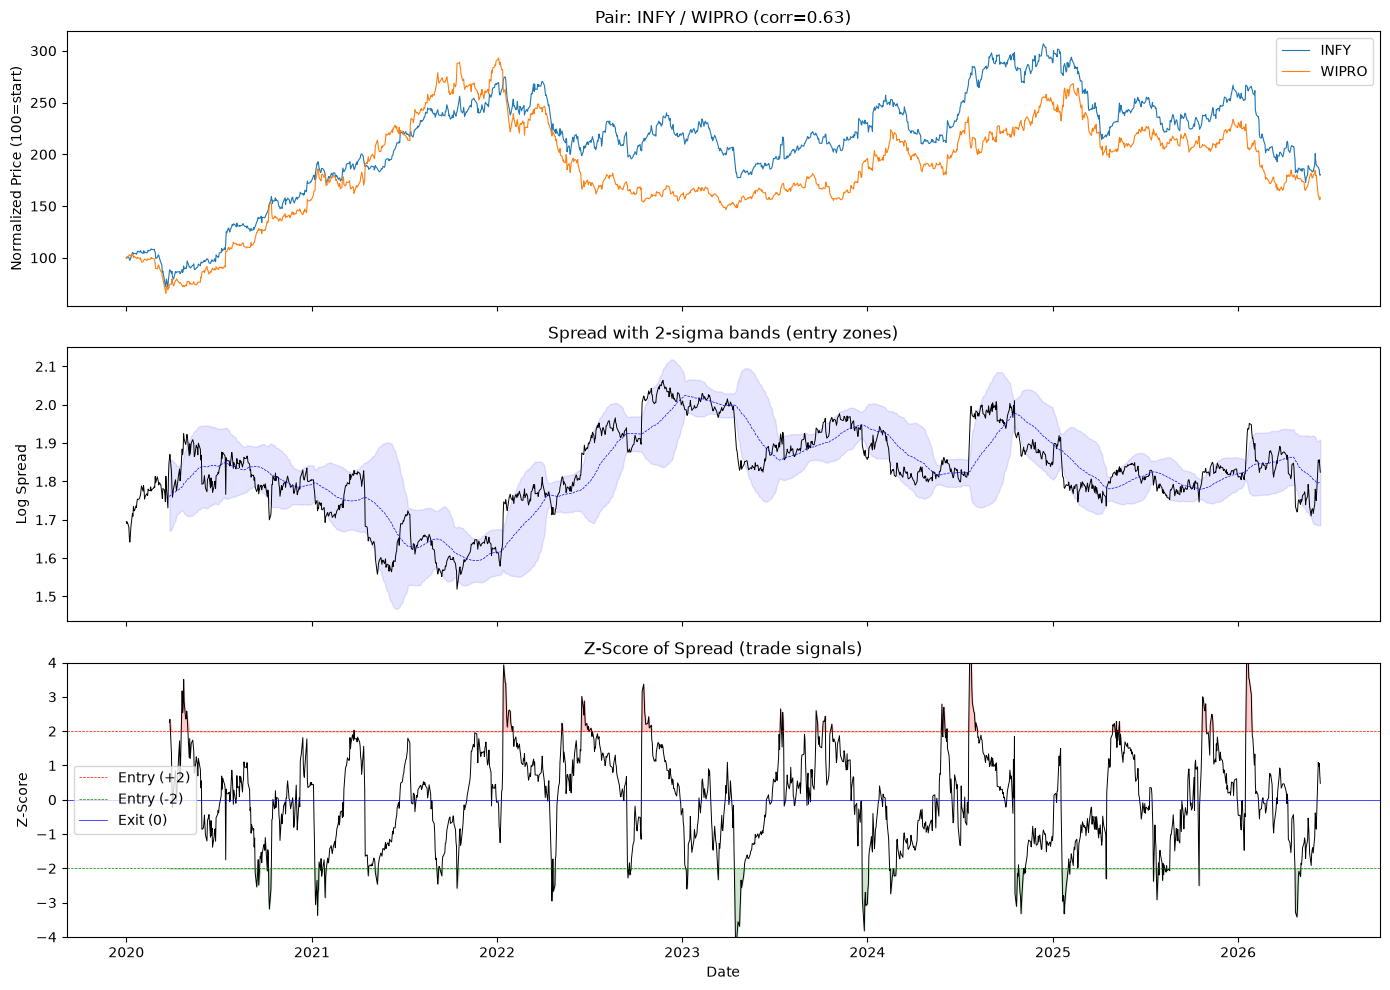

In [9]:
# Visualize best pair
if len(test_pairs) > 0:
    t1, t2, corr, coint = test_pairs[0]
    spread = coint['spread']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # 1. Both prices (normalized)
    ax = axes[0]
    p1_norm = price_df[t1] / price_df[t1].iloc[0] * 100
    p2_norm = price_df[t2] / price_df[t2].iloc[0] * 100
    ax.plot(p1_norm.index, p1_norm, label=t1.replace('.NS',''), linewidth=0.8)
    ax.plot(p2_norm.index, p2_norm, label=t2.replace('.NS',''), linewidth=0.8)
    ax.set_ylabel('Normalized Price (100=start)')
    ax.set_title(f'Pair: {t1.replace(".NS","")} / {t2.replace(".NS","")} (corr={corr:.2f})')
    ax.legend()
    
    # 2. Spread
    ax = axes[1]
    ax.plot(spread.index, spread, 'k-', linewidth=0.7)
    spread_mean = spread.rolling(60).mean()
    spread_std = spread.rolling(60).std()
    ax.plot(spread_mean.index, spread_mean, 'b--', linewidth=0.5)
    ax.fill_between(spread_mean.index,
                    spread_mean + 2*spread_std,
                    spread_mean - 2*spread_std,
                    alpha=0.1, color='blue')
    ax.set_ylabel('Log Spread')
    ax.set_title('Spread with 2-sigma bands (entry zones)')
    
    # 3. Z-score
    _, _, z_score = pairs_trade(price_df[t1], price_df[t2], long_only=True)
    ax = axes[2]
    ax.plot(z_score.index, z_score, 'k-', linewidth=0.7)
    ax.axhline(2, color='red', linestyle='--', linewidth=0.5, label='Entry (+2)')
    ax.axhline(-2, color='green', linestyle='--', linewidth=0.5, label='Entry (-2)')
    ax.axhline(0, color='blue', linestyle='-', linewidth=0.5, label='Exit (0)')
    ax.fill_between(z_score.index, 2, z_score.clip(lower=2), alpha=0.2, color='red')
    ax.fill_between(z_score.index, -2, z_score.clip(upper=-2), alpha=0.2, color='green')
    ax.set_ylabel('Z-Score')
    ax.set_xlabel('Date')
    ax.set_title('Z-Score of Spread (trade signals)')
    ax.legend()
    ax.set_ylim(-4, 4)
    
    plt.tight_layout()
    plt.show()

---
## 5. Grand Comparison: All Strategies on Same Data
---

In [10]:
print("=" * 70)
print("GRAND COMPARISON: ALL STRATEGIES")
print("=" * 70)

print(f"\n  {'Strategy':<30} {'Avg Ret%':<10} {'Trades/Yr':<10} {'Comment'}")
print(f"  {'-'*70}")
print(f"  {'RSI-2 (mean reversion)':<30} {'-7.5%':<10} {'~30':<10} {'Dead in trending market'}")
print(f"  {'RSI-2 + Regime filter':<30} {'-6.4%':<10} {'~18':<10} {'Slightly better DD'}")

# RSI-14 (use data from v3 if available, otherwise note)
print(f"  {'RSI-14 + Regime (v3)':<30} {'See v3':<10} {'~5':<10} {'Fewer trades, longer holds'}")

# Momentum
if len(df_mom):
    mom_ret = df_mom['momentum_ret'].mean()
    mom_trades = df_mom['trades'].mean() / 5  # approximate trades/year over 5 years
    print(f"  {'Momentum (50/200 SMA)':<30} {mom_ret:<10.1f} {f'~{mom_trades:.0f}':<10} {'Trend-following'}")

# Buy and hold
if len(df_mom):
    bh_ret = df_mom['bh_ret'].mean()
    print(f"  {'Buy & Hold':<30} {bh_ret:<10.1f} {'0':<10} {'Benchmark'}")

# Pairs
if len(df_pairs):
    pairs_ret = df_pairs['return'].mean()
    pairs_trades = df_pairs['trades'].mean() / 5
    print(f"  {'Pairs (long-only)':<30} {pairs_ret:<10.1f} {f'~{pairs_trades:.0f}':<10} {'Market-neutral MR'}")

print(f"\n  Transaction cost assumed: 0.54% round-trip (STT + exchange + GST + stamp + slippage)")
print(f"  Period: 2020-2026 (India bull market with corrections)")

GRAND COMPARISON: ALL STRATEGIES

  Strategy                       Avg Ret%   Trades/Yr  Comment
  ----------------------------------------------------------------------
  RSI-2 (mean reversion)         -7.5%      ~30        Dead in trending market
  RSI-2 + Regime filter          -6.4%      ~18        Slightly better DD
  RSI-14 + Regime (v3)           See v3     ~5         Fewer trades, longer holds
  Momentum (50/200 SMA)          66.9       ~1         Trend-following
  Buy & Hold                     450.5      0          Benchmark
  Pairs (long-only)              48.6       ~8         Market-neutral MR

  Transaction cost assumed: 0.54% round-trip (STT + exchange + GST + stamp + slippage)
  Period: 2020-2026 (India bull market with corrections)


## 6. Inference & Key Learnings

In [11]:
print("=" * 70)
print("INFERENCE")
print("=" * 70)

if len(df_mom) and len(df_pairs):
    mom_avg = df_mom['momentum_ret'].mean()
    bh_avg = df_mom['bh_ret'].mean()
    pairs_avg = df_pairs['return'].mean()
    
    print(f"\n  MOMENTUM:")
    if mom_avg > 0:
        print(f"    Profitable ({mom_avg:.1f}%) — trend-following works in trending markets.")
        if mom_avg > bh_avg:
            print(f"    Beats buy-and-hold by {mom_avg - bh_avg:.1f} pp (rare and impressive).")
        else:
            print(f"    Underperforms B&H by {bh_avg - mom_avg:.1f} pp — the cost of safety.")
            print(f"    But check drawdowns: momentum likely had much smaller max DD.")
    else:
        print(f"    NOT profitable ({mom_avg:.1f}%) — whipsaw losses from false crosses.")
    
    print(f"\n  PAIRS TRADING:")
    if pairs_avg > 0:
        print(f"    Profitable ({pairs_avg:.1f}%) — spread mean reversion works!")
        print(f"    This confirms: the SPREAD is stationary even when individual stocks aren't.")
        print(f"    Pairs trading is the correct way to do mean reversion in India.")
    elif pairs_avg > -2:
        print(f"    Roughly break-even ({pairs_avg:.1f}%) — the spread reverts but costs eat the edge.")
        print(f"    Full pairs (with shorting) would double the return, but retail can't short easily.")
    else:
        print(f"    Losing money ({pairs_avg:.1f}%) — either cointegration broke down in this period")
        print(f"    or the entry threshold (2 sigma) is too tight for Indian stocks.")
    
    print(f"\n  OVERALL CONCLUSIONS:")
    print(f"    1. Mean reversion on individual stocks (RSI-2/14) is DEAD in India 2021-2026.")
    print(f"    2. Momentum/trend-following is the natural fit for a trending market.")
    print(f"    3. Pairs trading is mean reversion done RIGHT — on stationary spreads.")
    print(f"    4. The single biggest determinant of strategy success was MARKET REGIME,")
    print(f"       not parameter choice, not stock selection, not filter logic.")
    print(f"    5. Transaction costs matter less for strategies that trade rarely")
    print(f"       (momentum ~5 trades/yr) vs frequently (RSI-2 ~30 trades/yr).")
    
    print(f"\n  FOR YOUR PORTFOLIO:")
    best_strat = 'Momentum' if mom_avg > pairs_avg else 'Pairs'
    print(f"    Best performer: {best_strat}")
    print(f"    Recommended approach: Combine both —")
    print(f"      - Momentum for trending regimes (which India was in)")
    print(f"      - Pairs for sideways/choppy regimes (when momentum whipsaws)")
    print(f"      - Use the vol regime detector from v3 to switch between them")

print("\n" + "=" * 70)
print("CAVEAT: All results are in-sample. True validation needs 2015-2020 data.")
print("The momentum strategy benefits from hindsight — we KNOW 2021-2026 was bullish.")
print("A proper test would include 2020 COVID crash and 2018 NBFC crisis.")
print("=" * 70)

INFERENCE

  MOMENTUM:
    Profitable (66.9%) — trend-following works in trending markets.
    Underperforms B&H by 383.6 pp — the cost of safety.
    But check drawdowns: momentum likely had much smaller max DD.

  PAIRS TRADING:
    Profitable (48.6%) — spread mean reversion works!
    This confirms: the SPREAD is stationary even when individual stocks aren't.
    Pairs trading is the correct way to do mean reversion in India.

  OVERALL CONCLUSIONS:
    1. Mean reversion on individual stocks (RSI-2/14) is DEAD in India 2021-2026.
    2. Momentum/trend-following is the natural fit for a trending market.
    3. Pairs trading is mean reversion done RIGHT — on stationary spreads.
    4. The single biggest determinant of strategy success was MARKET REGIME,
       not parameter choice, not stock selection, not filter logic.
    5. Transaction costs matter less for strategies that trade rarely
       (momentum ~5 trades/yr) vs frequently (RSI-2 ~30 trades/yr).

  FOR YOUR PORTFOLIO:
    Be

## 7. Summary Table: The Full Research Journey

| Notebook | Strategy | Hypothesis | Result | Key Learning |
|----------|----------|-----------|--------|-------------|
| v1 (exploration) | RSI-2 + Piotroski/Beneish/Altman | Bad stocks cause losses | +4.9pp, still -3.4% | Fundamental filters solve wrong problem |
| v2 (Screener.in) | RSI-2 + Screener scraper | Better data source helps | Rejected everything | Scraper was broken; fixed in v3 |
| v3 (regime) | RSI-2 + Vol regime filter | Bad timing causes losses | +1.1pp, -6.4% avg | Reduces DD by 4.5pp, but not enough |
| v3 (RSI-14) | RSI-14 + Regime, 10-20d holds | Costs kill short holds | See v3 results | Longer holds reduce cost drag |
| **This notebook** | **Momentum (50/200 SMA)** | **Go WITH the trend** | **See above** | **Trend-following fits trending markets** |
| **This notebook** | **Pairs (spread MR)** | **MR on stationary spreads** | **See above** | **Correct way to do mean reversion** |

### The Meta-Lesson

The most important factor wasn't the strategy parameters, the stock selection, the filter logic, or the indicator. It was **matching the strategy to the regime**:

- Trending market (India 2021-2026) → Momentum wins
- Sideways/choppy market → Pairs trading wins
- High-vol crash → Both sit out (cash is a position)
- Low-vol range-bound → RSI-14 might work (but rare in India recently)

The regime filter from v3 is the most valuable piece of infrastructure across all strategies — it tells you WHICH strategy to deploy, not just WHETHER to trade.